In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

df = pd.read_csv("../Datasets/car_rental_cleaned_dataset.csv")

required_defaults = {
    "Reservation_ID": "",
    "Customer_ID": "",
    "Vehicle_ID": "",
    "Vehicle_Class": "Unknown",
    "Booking_Status": "Unknown",
    "Booking_TS": pd.NaT,
    "Pickup_TS": pd.NaT,
    "Return_TS": pd.NaT,
    "Odo_Start": np.nan,
    "Odo_End": np.nan,
    "Fuel_Level": np.nan,
    "Rate": np.nan,
    "Promo_Code": "",
    "City": "Unknown",
    "GPS_Lat": np.nan,
    "GPS_Lon": np.nan,
    "Speed": np.nan,
    "Damage_Flag": "None",
    "Notes": "",
    "Vehicle_ID_Invalid": False,
    "Duration_Hours": np.nan,
    "expected_hours": np.nan,
    "Distance_Driven": np.nan,
    "Refuel_Event": "",
    "Driver_Behavior": "Unknown",
    "Total_Amount": np.nan,
}
for col, default in required_defaults.items():
    if col not in df.columns:
        df[col] = default

for col in ["Booking_TS", "Pickup_TS", "Return_TS", "Prev_Return", "Promo_Expiry"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

for col in ["Duration_Hours", "expected_hours", "Distance_Driven", "Odo_Start", "Odo_End", "Rate", "Total_Amount", "Fuel_Level", "Speed", "GPS_Lat", "GPS_Lon"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

bool_values = df["Vehicle_ID_Invalid"].astype(str).str.lower().str.strip()
df["vehicle_id_invalid_flag"] = bool_values.isin(["true", "1", "yes"])

df["is_completed"] = df["Booking_Status"].eq("Completed")
df["rental_hours"] = df["Duration_Hours"]
mask_missing_hours = df["rental_hours"].isna() & df["Pickup_TS"].notna() & df["Return_TS"].notna()
df.loc[mask_missing_hours, "rental_hours"] = (
    (df.loc[mask_missing_hours, "Return_TS"] - df.loc[mask_missing_hours, "Pickup_TS"]).dt.total_seconds() / 3600
)
df["rental_hours"] = df["rental_hours"].clip(lower=0)

df["distance_km"] = df["Distance_Driven"].clip(lower=0)
df["lead_time_hours"] = ((df["Pickup_TS"] - df["Booking_TS"]).dt.total_seconds() / 3600).clip(lower=0)
df["booking_month"] = df["Booking_TS"].dt.to_period("M").astype(str)
df["pickup_date"] = df["Pickup_TS"].dt.date

a_start = df["Pickup_TS"].min()
a_end = df["Return_TS"].max()
analysis_hours = max((a_end - a_start).total_seconds() / 3600, 1) if pd.notna(a_start) and pd.notna(a_end) else 1

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Analysis window hours: {analysis_hours:,.2f}")
print(df[["Reservation_ID", "City", "Vehicle_Class", "Booking_Status", "rental_hours", "expected_hours", "distance_km", "Rate", "Total_Amount"]].head())

Rows: 4,527 | Columns: 39
Analysis window hours: 8,159.15
  Reservation_ID     City Vehicle_Class Booking_Status  rental_hours  expected_hours  distance_km     Rate  Total_Amount
0      RES-00003    Delhi        Suzuki      Completed         71.00           71.00       382.00 2,000.00      2,360.00
1      RES-03655   Mumbai        Suzuki      Completed         28.00           28.00       211.00 2,300.00      2,714.00
2      RES-01774   Mumbai        Suzuki      Cancelled          3.00            3.00         0.00 1,840.00          0.00
3      RES-03809  Chennai        Suzuki      Cancelled         38.00           38.00         0.00 2,000.00          0.00
4      RES-01293   Mumbai        Suzuki      Cancelled      2,163.00        2,163.00         0.00 1,500.00          0.00


## 1) Utilization = rental hours / fleet hours by city and vehicle class


     City Vehicle_Class  available_cars  fleet_hours  rental_hours  utilization
    Delhi           SUV              13    76,309.39     57,835.44         0.76
Bengaluru        Toyota              10    56,872.98     42,669.97         0.75
  Chennai         Sedan              15    83,321.07     54,094.13         0.65
   Mumbai        Toyota              17    98,207.23     59,256.75         0.60
  Chennai        Suzuki               9    56,079.77     32,709.91         0.58
   Mumbai           SUV              18   104,014.07     56,395.49         0.54
  Chennai            EV               9    56,481.72     27,611.10         0.49


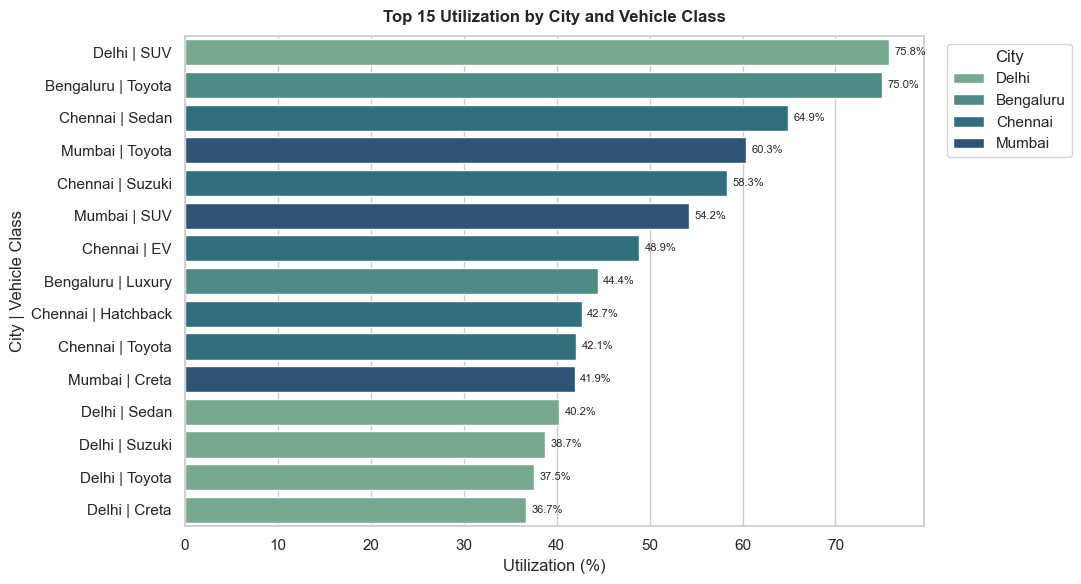

In [114]:
vehicle_activity = df.groupby("Vehicle_ID").agg(
    first_use=("Pickup_TS", "min"),
    last_use=("Return_TS", "max"),
    City=("City", "first"),
    Vehicle_Class=("Vehicle_Class", "first")
).reset_index()

vehicle_activity["active_hours"] = (
    vehicle_activity["last_use"] - vehicle_activity["first_use"]
).dt.total_seconds() / 3600

fleet = vehicle_activity.groupby(["City", "Vehicle_Class"], dropna=False).agg(
    available_cars=("Vehicle_ID", "nunique"),
    fleet_hours=("active_hours", "sum")
)

rental = df.loc[df["is_completed"]].groupby(
    ["City", "Vehicle_Class"], dropna=False
)["rental_hours"].sum().rename("rental_hours")

util = pd.concat([fleet, rental], axis=1).fillna(0).reset_index()

util["utilization"] = np.where(
    util["fleet_hours"] > 0,
    util["rental_hours"] / util["fleet_hours"],
    0
)

util = util.sort_values("utilization", ascending=False)

print(util.head(7).to_string(index=False))

top_util = util.head(15).copy()
top_util["utilization_pct"] = (top_util["utilization"] * 100).round(2)
top_util["segment"] = top_util["City"].astype(str) + " | " + top_util["Vehicle_Class"].astype(str)
top_util = top_util.sort_values("utilization_pct", ascending=False)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=top_util,
    x="utilization_pct",
    y="segment",
    hue="City",
    palette="crest",
    dodge=False,
)
ax.set_title("Top 15 Utilization by City and Vehicle Class", pad=10, weight="bold")
ax.set_xlabel("Utilization (%)")
ax.set_ylabel("City | Vehicle Class")

for i, v in enumerate(top_util["utilization_pct"]):
    ax.text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=8)

ax.legend(title="City", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

## 2) Revenue per available car (RevPAC) and yield metrics


In [115]:
completed = df[df["is_completed"]].copy()

metrics = completed.groupby(["City","Vehicle_Class"], dropna=False).agg(
    total_revenue=("Total_Amount","sum"),
    rental_hours=("rental_hours","sum")
).reset_index()

rev_metrics = util[["City","Vehicle_Class","available_cars"]].merge(
    metrics,
    on=["City","Vehicle_Class"],
    how="left"
).fillna(0)

rev_metrics["RevPAC"] = rev_metrics["total_revenue"] / rev_metrics["available_cars"]
rev_metrics["yield_per_hour"] = rev_metrics["total_revenue"] / rev_metrics["rental_hours"]

pd.options.display.float_format = "{:,.2f}".format

result = rev_metrics[
    ["City","Vehicle_Class","available_cars","total_revenue","RevPAC","yield_per_hour"]
].sort_values("RevPAC", ascending=False)

print(result.head(7).to_string(index=False))

     City Vehicle_Class  available_cars  total_revenue    RevPAC  yield_per_hour
    Delhi           SUV              13     145,779.68 11,213.82            2.52
  Chennai        Suzuki               9      71,203.06  7,911.45            2.18
Bengaluru        Toyota              10      78,188.66  7,818.87            1.83
  Chennai            EV               9      64,429.24  7,158.80            2.33
    Delhi        Suzuki              19     125,812.84  6,621.73            3.03
  Chennai        Toyota              13      82,107.50  6,315.96            2.46
   Mumbai         Creta              18     113,094.92  6,283.05            2.49


## 3) Distance driven and cost per km


     City Vehicle_Class  total_distance_km  cost_per_km  trips
Bengaluru         Creta           8,746.00        23.91     44
Bengaluru            EV           7,544.00        21.07     36
Bengaluru     Hatchback           9,160.00        19.09     42
Bengaluru        Luxury          11,324.00        16.71     44
Bengaluru           SUV           7,488.00        21.02     38
Bengaluru         Sedan          11,066.00        15.28     38
Bengaluru        Suzuki           8,887.00        20.43     45


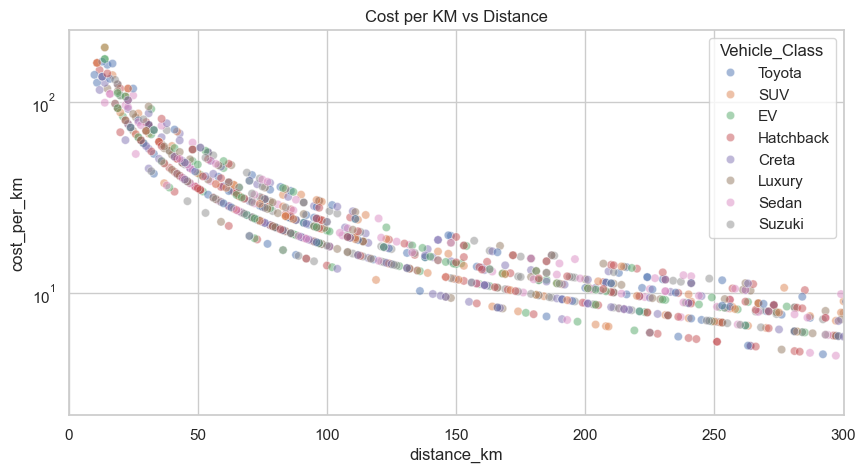

In [116]:
min_distance_km = 10

# Filter valid trips
trip = df[
    (df["is_completed"]) &
    (df["distance_km"] >= min_distance_km) &
    (df["Total_Amount"] > 0)
].copy()

# Cost per km
trip["cost_per_km"] = trip["Total_Amount"] / trip["distance_km"]

# Remove extreme outliers (top 1%)
trip = trip[
    (trip["distance_km"] <= trip["distance_km"].quantile(0.99)) &
    (trip["cost_per_km"] <= trip["cost_per_km"].quantile(0.99))
]

# Aggregated metrics
distance_cost = trip.groupby(["City", "Vehicle_Class"]).agg(
    total_distance_km=("distance_km", "sum"),
    cost_per_km=("cost_per_km", "mean"),
    trips=("Reservation_ID", "count")
).reset_index()

print(distance_cost.head(7).to_string(index=False))

# Plot
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=trip.sample(min(len(trip), 2000), random_state=42),
    x="distance_km",
    y="cost_per_km",
    hue="Vehicle_Class",
    alpha=0.5
)

plt.yscale("log")
plt.title("Cost per KM vs Distance")
plt.xlabel("distance_km")
plt.ylabel("cost_per_km")
plt.xlim(0, 300)
plt.show()

## 4) Idle time and repositioning analytics


In [117]:
seq = df.sort_values(["Vehicle_ID", "Pickup_TS"])

# get previous trip return time and city for the same vehicle
seq["prev_return_ts"] = seq.groupby("Vehicle_ID")["Return_TS"].shift()
seq["prev_city"] = seq.groupby("Vehicle_ID")["City"].shift()

# calculate idle time between trips
seq["idle_hours"] = (seq["Pickup_TS"] - seq["prev_return_ts"]).dt.total_seconds() / 3600
seq["idle_hours"] = seq["idle_hours"].clip(lower=0)

# check if vehicle moved to a different city
seq["repositioned"] = (seq["City"] != seq["prev_city"]) & seq["prev_city"].notna()

idle_summary = seq.groupby("Vehicle_ID").agg(
    avg_idle_hours=("idle_hours", "mean"),
    reposition_events=("repositioned", "sum")
).reset_index()

print(idle_summary.head(7).to_string(index=False))
print(idle_summary.shape)

Vehicle_ID  avg_idle_hours  reposition_events
   CAR-001          816.33                  4
   CAR-002          770.36                  4
   CAR-003          434.77                  6
   CAR-005          446.77                  8
   CAR-006          714.11                  2
   CAR-007          367.31                  1
   CAR-008          774.27                  5
(600, 3)


## 5) Dynamic pricing features (demand, lead time, seasonality)


   City Vehicle_Class  lead_time_hours  daily_demand
 Mumbai        Luxury             0.75            10
Chennai     Hatchback             0.77             4
Chennai         Sedan             1.03             6
Chennai        Luxury            17.78             5
Chennai     Hatchback            18.55             6
 Mumbai         Sedan            18.87            10
Chennai        Luxury            19.00             9
     City Vehicle_Class  month  daily_demand
Bengaluru         Creta      1          8.60
Bengaluru         Creta      2          6.69
Bengaluru         Creta      3          6.37
Bengaluru         Creta      4          7.33
Bengaluru         Creta      5          7.96
Bengaluru         Creta      6          7.67
Bengaluru         Creta      7          4.40


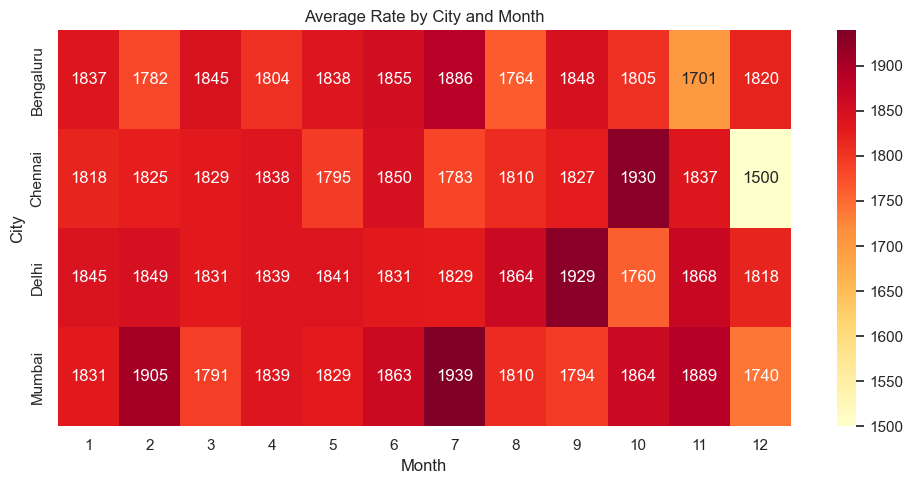

In [118]:
pricing = df.copy()
pricing["month"] = pricing["Pickup_TS"].dt.month

pricing["daily_demand"] = pricing.groupby(["City", "pickup_date"])["Reservation_ID"].transform("count")
pricing = pricing.sort_values("lead_time_hours", ascending=True)

print(pricing[["City","Vehicle_Class","lead_time_hours","daily_demand"]].head(7).to_string(index=False))

# show average daily demand by month
monthly_demand = pricing.groupby(
    ["City","Vehicle_Class","month"]
)["daily_demand"].mean().reset_index()

print(monthly_demand.head(7).to_string(index=False))
plt.figure(figsize=(10,5))

heat_data = pricing.pivot_table(
    values="Rate",
    index="City",
    columns="month",
    aggfunc="mean"
)

sns.heatmap(
    heat_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.title("Average Rate by City and Month")
plt.xlabel("Month")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## 6) Fuel efficiency estimates by model


Vehicle_Class  trips  avg_fuel_efficiency
       Luxury    163             1,166.27
       Suzuki    181             1,162.61
        Creta    210             1,054.67
       Toyota    191               972.36
        Sedan    191               905.45
    Hatchback    212               811.67
          SUV    171               791.95


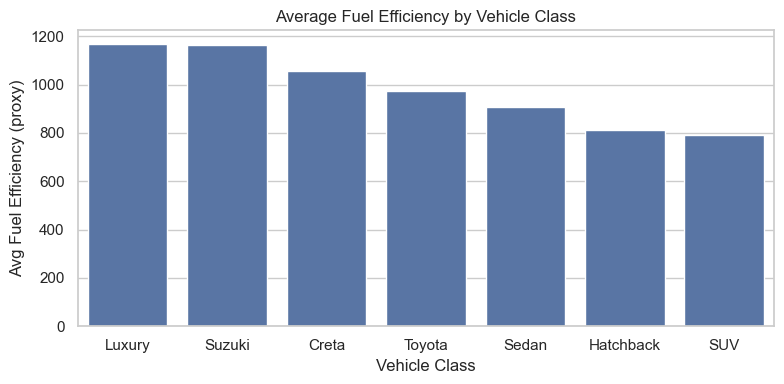

In [119]:
fuel = df[(df["is_completed"]) & (df["distance_km"] > 0)].copy()

fuel["fuel_used_proxy"] = (
    1 - fuel["Fuel_Level"].fillna(fuel["Fuel_Level"].median())
).clip(0.05, 1)

fuel["fuel_efficiency_proxy"] = fuel["distance_km"] / fuel["fuel_used_proxy"]

fuel_eff = fuel.groupby("Vehicle_Class", dropna=False).agg(
    trips=("Reservation_ID", "count"),
    avg_fuel_efficiency=("fuel_efficiency_proxy", "mean")
).round(2).reset_index().sort_values("avg_fuel_efficiency", ascending=False)

fuel_eff = fuel_eff[fuel_eff["Vehicle_Class"] != "EV"]
print((fuel_eff).to_string(index=False))

fuel_eff_plot = fuel_eff[fuel_eff["Vehicle_Class"] != "EV"]
plt.figure(figsize=(8,4))

sns.barplot(
    data=fuel_eff_plot,
    x="Vehicle_Class",
    y="avg_fuel_efficiency"
)

plt.title("Average Fuel Efficiency by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Avg Fuel Efficiency (proxy)")
plt.tight_layout()
plt.show()

## 7) Damage incidence rate per 100 rentals


     City Vehicle_Class  rentals  damage_events  damage_per_100_rentals
Bengaluru        Toyota      117             91                   77.78
  Chennai         Sedan      111             82                   73.87
   Mumbai        Luxury      108             79                   73.15
Bengaluru            EV      128             93                   72.66
   Mumbai         Sedan      117             84                   71.79
   Mumbai        Toyota      145            103                   71.03
   Mumbai         Creta      187            132                   70.59


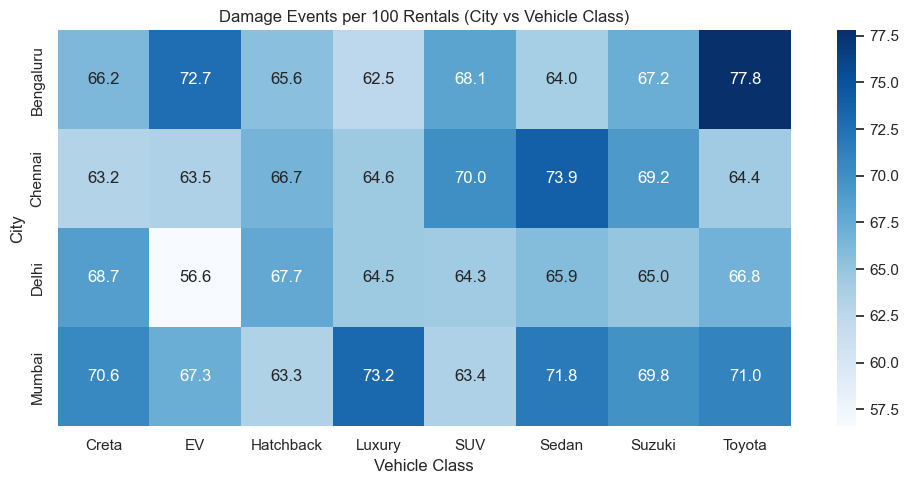

In [120]:
damage = df.copy()

damage["damage_event"] = damage["Damage_Flag"].fillna("None") != "None"

damage_rate = damage.groupby(["City", "Vehicle_Class"]).agg(
    rentals=("Reservation_ID", "count"),
    damage_events=("damage_event", "sum")
).reset_index()

damage_rate["damage_per_100_rentals"] = (
    100 * damage_rate["damage_events"] / damage_rate["rentals"]
).round(2)

print(damage_rate.sort_values("damage_per_100_rentals", ascending=False).head(7).to_string(index=False))

pivot_damage = damage_rate.pivot(
    index="City",
    columns="Vehicle_Class",
    values="damage_per_100_rentals"
)

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot_damage,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Damage Events per 100 Rentals (City vs Vehicle Class)")
plt.xlabel("Vehicle Class")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## 8) Customer cohort retention and NPS rollups


In [121]:
cust = df[df["is_completed"]].copy()
cust["booking_month_period"] = cust["Booking_TS"].dt.to_period("M")
cohort_month = cust.groupby("Customer_ID")["booking_month_period"].min().rename("cohort_month")
cust = cust.join(cohort_month, on="Customer_ID")

valid = cust.dropna(subset=["booking_month_period", "cohort_month"]).copy()
valid["cohort_index"] = valid["booking_month_period"].astype(int) - valid["cohort_month"].astype(int)

ret_counts = valid.groupby(["cohort_month", "cohort_index"])["Customer_ID"].nunique().unstack(fill_value=0)
if not ret_counts.empty:
    base = ret_counts.iloc[:, 0]
    retention = ret_counts.div(base, axis=0).round(3)
    print("Retention matrix (first rows):")
    print(retention.head(7))
else:
    print("Retention matrix unavailable (insufficient date data).")

valid["nps_bucket"] = np.select(
    [
        (valid["Driver_Behavior"].eq("Normal Driving") | valid["Damage_Flag"].eq("None")),
        (valid["Driver_Behavior"].isin(["Speeding", "Fast Driving"]) | valid["Damage_Flag"].eq("Major")),
    ],
    ["Promoter", "Detractor"],
    default="Passive",
)

nps_rollup = valid.groupby("cohort_month")["nps_bucket"].value_counts(normalize=True).unstack(fill_value=0)
nps_rollup["NPS"] = (nps_rollup.get("Promoter", 0) - nps_rollup.get("Detractor", 0)) * 100
print("\nNPS by cohort month:")
print(nps_rollup[[c for c in ["Promoter", "Passive", "Detractor", "NPS"] if c in nps_rollup.columns]].head(7))


Retention matrix (first rows):
cohort_index   0    1    2    3    4    5    6    7    8    9    10
cohort_month                                                       
2024-12      1.00 0.07 0.09 0.11 0.07 0.11 0.04 0.00 0.00 0.00 0.02
2025-01      1.00 0.09 0.12 0.09 0.10 0.10 0.01 0.00 0.00 0.00 0.00
2025-02      1.00 0.15 0.13 0.11 0.08 0.00 0.00 0.01 0.01 0.01 0.00
2025-03      1.00 0.08 0.07 0.11 0.01 0.00 0.00 0.00 0.00 0.00 0.00
2025-04      1.00 0.09 0.07 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00
2025-05      1.00 0.10 0.00 0.01 0.00 0.00 0.00 0.00 0.00 0.00 0.00
2025-06      1.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00

NPS by cohort month:
nps_bucket    Promoter  Passive  Detractor    NPS
cohort_month                                     
2024-12           0.30     0.15       0.55 -25.35
2025-01           0.26     0.15       0.60 -34.14
2025-02           0.33     0.10       0.57 -24.14
2025-03           0.31     0.16       0.53 -21.34
2025-04           0.24     0.17    

## 9) Fraud risk score (short returns, odometer anomalies)


     City  high_risk_pct  total_reservations
   Mumbai           0.38                1061
Bengaluru           0.19                1041
  Chennai           0.13                 798
    Delhi           0.12                1627


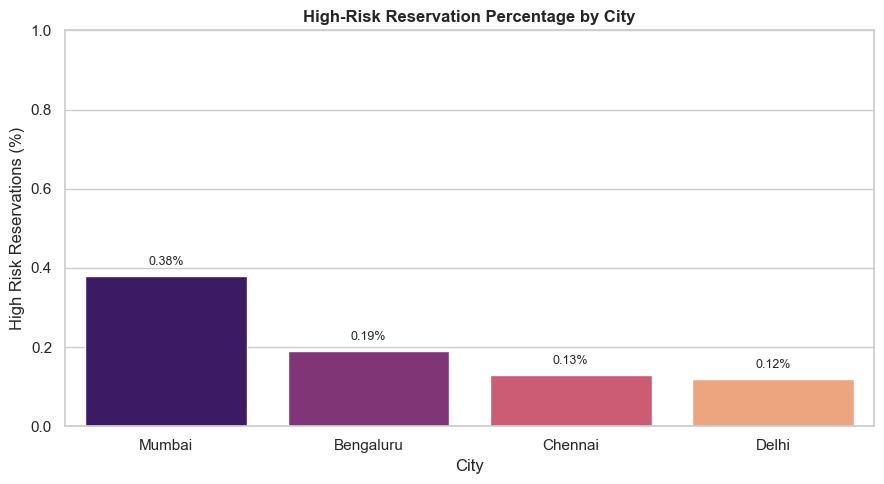

In [122]:
# High-risk percentage by city

fraud = df.copy()

# Build fraud risk score
fraud["short_return_flag"] = fraud["is_completed"] & (fraud["rental_hours"] < 2)
fraud["odo_diff"] = fraud["Odo_End"] - fraud["Odo_Start"]
fraud["odo_anomaly_flag"] = (fraud["odo_diff"] < 0) | ((fraud["odo_diff"] - fraud["distance_km"]).abs() > 50)
fraud["speed_risk_flag"] = fraud["Speed"] > 120

fraud["fraud_risk_score"] = (
    30 * fraud["short_return_flag"].astype(int)
    + 50 * fraud["odo_anomaly_flag"].fillna(False).astype(int)
    + 20 * fraud["speed_risk_flag"].fillna(False).astype(int)
    + 20 * fraud["vehicle_id_invalid_flag"].astype(int)
).clip(0, 100)

# High risk = score >= 50
city_high_risk = (
    fraud.assign(high_risk=fraud["fraud_risk_score"] >= 50)
    .groupby("City", dropna=False)
    .agg(high_risk_pct=("high_risk", "mean"), total_reservations=("Reservation_ID", "count"))
    .reset_index()
    .sort_values("high_risk_pct", ascending=False)
)

city_high_risk["high_risk_pct"] = (city_high_risk["high_risk_pct"] * 100).round(2)
print(city_high_risk[["City", "high_risk_pct", "total_reservations"]].head(7).to_string(index=False))

# Simple graph: high-risk percentage by city
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=city_high_risk,
    x="City",
    y="high_risk_pct",
    hue="City",
    palette="magma",
    legend=False,
 )
ax.set_title("High-Risk Reservation Percentage by City", weight="bold")
ax.set_xlabel("City")
ax.set_ylabel("High Risk Reservations (%)")

max_pct = city_high_risk["high_risk_pct"].max()
ax.set_ylim(0, max(max_pct * 1.35, 1))

offset = max(max_pct * 0.03, 0.02)
for i, v in enumerate(city_high_risk["high_risk_pct"]):
    ax.text(i, v + offset, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 10) Maintenance due forecast (km/time based)


In [123]:
# Filter to Completed trips only — odometer readings are only meaningful here
df_completed = df[df["Booking_Status"] == "Completed"]

latest = (
    df_completed
    .sort_values("Return_TS")
    .groupby("Vehicle_ID", as_index=False)
    .tail(1)
    .copy()
)

latest["curr_odometer"] = latest["Odo_End"].fillna(latest["Odo_Start"])
latest["next_service_km"] = 10000 - (latest["curr_odometer"] % 10000)
latest["last_return_days"] = (
    pd.Timestamp.today().normalize() - latest["Return_TS"]
).dt.days

latest["maintenance_due"] = (
    (latest["next_service_km"] <= 500) | (latest["last_return_days"] >= 180)
)

# Fix: clip days score at 1, not 2, so final score stays in [0, 1]
latest["maintenance_priority"] = (
    ((500 - latest["next_service_km"]).clip(lower=0) / 500) * 0.6
    + (latest["last_return_days"].clip(lower=0) / 180).clip(upper=1) * 0.4
)

print(
    latest[[
        "Vehicle_ID", "Vehicle_Class", "curr_odometer",
        "next_service_km", "last_return_days",
        "maintenance_due", "maintenance_priority"
    ]]
    .sort_values(["maintenance_due", "maintenance_priority"], ascending=[False, False])
    .head(7).to_string(index=False)
)

Vehicle_ID Vehicle_Class  curr_odometer  next_service_km  last_return_days  maintenance_due  maintenance_priority
   CAR-173        Suzuki      59,935.00            65.00               230             True                  0.92
   CAR-186        Toyota      69,928.00            72.00               303             True                  0.91
   CAR-582        Suzuki      59,910.00            90.00               296             True                  0.89
   CAR-567         Sedan      49,894.00           106.00               352             True                  0.87
   CAR-207     Hatchback      59,952.00            48.00               137             True                  0.85
   CAR-153        Toyota      49,870.00           130.00               227             True                  0.84
   CAR-552         Sedan      59,864.00           136.00               275             True                  0.84


## 11) Overstay detection and penalty calculation


Rows evaluated: 1,487
Rows with overstay_hours > 0: 136

Top Overstay Results (expected_hours - Duration_Hours)
     Reservation_ID Vehicle_Class  overstay_hours  overstay_penalty
944       RES-01058         Creta            8.90            226.21
4232      RES-01562         Sedan            8.79            217.29
3459      RES-00796     Hatchback            8.73            238.76
833       RES-00007         Creta            8.69            237.05
2011      RES-03490            EV            8.68            236.70
3612      RES-01003        Suzuki            8.68            177.51
3116      RES-01506        Suzuki            8.67            212.44


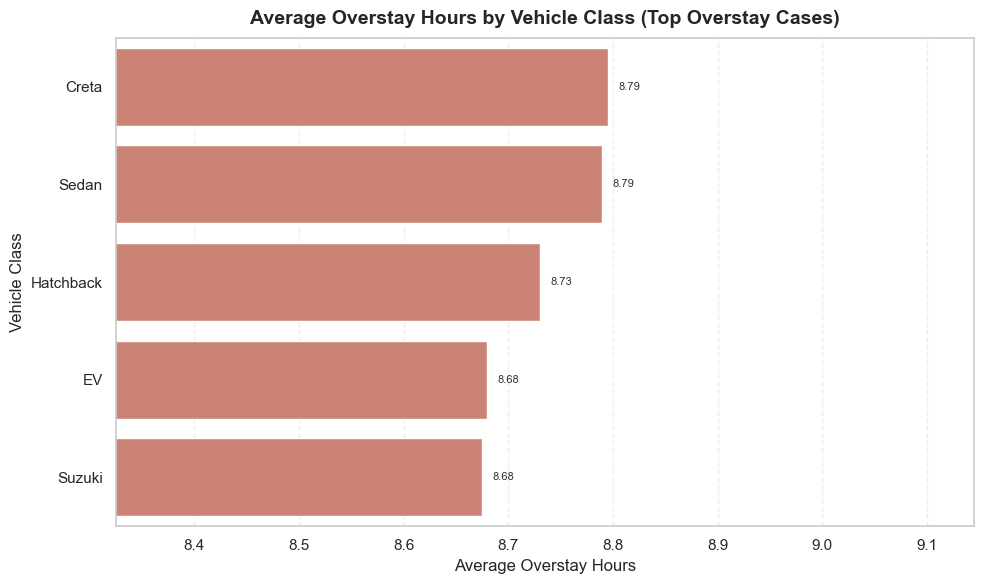

In [136]:
overstay = df[df["is_completed"]].copy()
overstay = overstay[
    (overstay["Rate"] > 0)
    & overstay["Duration_Hours"].notna()
    & overstay["expected_hours"].notna()
] .copy()

# Requested simple logic: expected_hours - Duration_Hours
overstay["overstay_hours"] = (
    overstay["expected_hours"] - overstay["Duration_Hours"]
).clip(lower=0)

# Penalty calculation
overstay["hourly_rate"] = overstay["Rate"] / 24
h = overstay["overstay_hours"].clip(upper=72)
overstay["penalty_first_6h"] = np.minimum(h, 6) * 0.25 * overstay["hourly_rate"]
overstay["penalty_next_18h"] = np.minimum(np.clip(h - 6, 0, None), 18) * 0.50 * overstay["hourly_rate"]
overstay["penalty_after_24h"] = np.clip(h - 24, 0, None) * 1.00 * overstay["hourly_rate"]
overstay["overstay_penalty"] = (
    overstay["penalty_first_6h"]
    + overstay["penalty_next_18h"]
    + overstay["penalty_after_24h"]
)

# Final hard cap
overstay["overstay_penalty"] = np.minimum(overstay["overstay_penalty"], overstay["Rate"] * 1.25)

overstay_positive = overstay[overstay["overstay_hours"] > 0].copy()

print(f"Rows evaluated: {len(overstay):,}")
print(f"Rows with overstay_hours > 0: {len(overstay_positive):,}")

imp_cols = [
    "Reservation_ID",
    "Vehicle_Class",
    "overstay_hours",
    "overstay_penalty",
]
top_overstay = overstay_positive[imp_cols].sort_values(
    ["overstay_hours", "overstay_penalty"], ascending=False
).head(7).round(2)

print("\nTop Overstay Results (expected_hours - Duration_Hours)")
print(top_overstay)

# Vehicle class only graph: average overstay hours
class_overstay = (
    top_overstay.groupby("Vehicle_Class", dropna=False)
    .agg(
        avg_overstay_hours=("overstay_hours", "mean"),
        cases=("Reservation_ID", "count"),
    )
    .reset_index()
    .sort_values("avg_overstay_hours", ascending=False)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=class_overstay,
    y="Vehicle_Class",
    x="avg_overstay_hours",
    color="#d87a66",
)

ax.set_title("Average Overstay Hours by Vehicle Class (Top Overstay Cases)", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("Average Overstay Hours")
ax.set_ylabel("Vehicle Class")
ax.grid(axis="x", linestyle="--", alpha=0.35)

xmin = max(class_overstay["avg_overstay_hours"].min() - 0.35, 0)
xmax = class_overstay["avg_overstay_hours"].max() + 0.35
ax.set_xlim(xmin, xmax)

for i, row in class_overstay.reset_index(drop=True).iterrows():
    ax.text(
        row["avg_overstay_hours"] + 0.01,
        i,
        f"{row['avg_overstay_hours']:.2f}",
        va="center",
        fontsize=8,
        color="#333333",
    )

plt.tight_layout()
plt.show()

## 12) Pickup/return punctuality stats


In [ ]:
completed = df[df["is_completed"]].copy()

# Pickup punctuality: compare lead time with city median lead time
pickup = completed.dropna(subset=["Booking_TS", "Pickup_TS"]).copy()
pickup["lead_time_hours"] = (pickup["Pickup_TS"] - pickup["Booking_TS"]).dt.total_seconds() / 3600
pickup = pickup[pickup["lead_time_hours"].between(0, 72)].copy()

city_median_lead = pickup.groupby("City", dropna=False)["lead_time_hours"].transform("median")
pickup["pickup_deviation_min"] = ((pickup["lead_time_hours"] - city_median_lead) * 60).abs()
pickup["pickup_consistent"] = pickup["pickup_deviation_min"] <= 120
pickup["pickup_deviation_min_report"] = pickup["pickup_deviation_min"].clip(upper=180)

pickup_stats = pickup.groupby("City", dropna=False).agg(
    pickup_consistency_rate=("pickup_consistent", lambda s: s.mean() * 100),
    avg_pickup_deviation_min=("pickup_deviation_min_report", "mean"),
).reset_index()

# Return punctuality: compare actual duration with expected duration
ret = completed.dropna(subset=["Duration_Hours", "expected_hours"]).copy()
ret["return_deviation_min"] = ((ret["Duration_Hours"] - ret["expected_hours"]) * 60).abs()
ret_cap = ret.groupby("City", dropna=False)["return_deviation_min"].transform(lambda s: s.quantile(0.99))
ret["return_deviation_min"] = np.minimum(ret["return_deviation_min"], ret_cap)
ret["return_on_time"] = ret["return_deviation_min"] <= 30

return_stats = ret.groupby("City", dropna=False).agg(
    return_on_time_rate=("return_on_time", lambda s: s.mean() * 100),
    avg_return_delay_min=("return_deviation_min", "mean"),
).reset_index()

punct_view = (
    pickup_stats.merge(return_stats, on="City", how="outer")
    [[
        "City",
        "pickup_consistency_rate",
        "return_on_time_rate",
        "avg_pickup_deviation_min",
        "avg_return_delay_min",
    ]]
    .round(2)
    .sort_values("City")
)

print(punct_view)

City,pickup_consistency_rate,return_on_time_rate,avg_pickup_deviation_min,avg_return_delay_min,pickup_metric_coverage_pct,return_metric_coverage_pct,avg_pickup_tolerance_min
Bengaluru,59.14,89.71,41.70,41.78,75.59,100.00,143.58
Chennai,58.30,90.71,175.29,35.79,79.64,100.00,156.19
Delhi,64.48,91.06,21.78,33.71,78.14,100.00,138.32
Mumbai,59.92,91.79,124.92,33.04,76.83,100.00,157.44


## 13) Geo heatmaps of pickup/drop hotspots


     City  lat_bin  lon_bin  bookings
64  Delhi    28.62    77.20        41
55  Delhi    28.60    77.21        36
61  Delhi    28.61    77.22        36
60  Delhi    28.61    77.21        34
71  Delhi    28.63    77.22        32
69  Delhi    28.63    77.20        32
56  Delhi    28.60    77.22        30


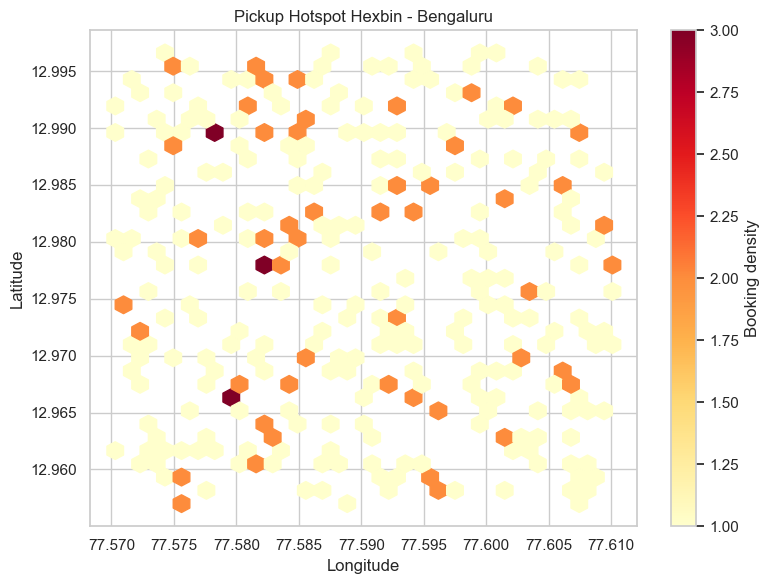

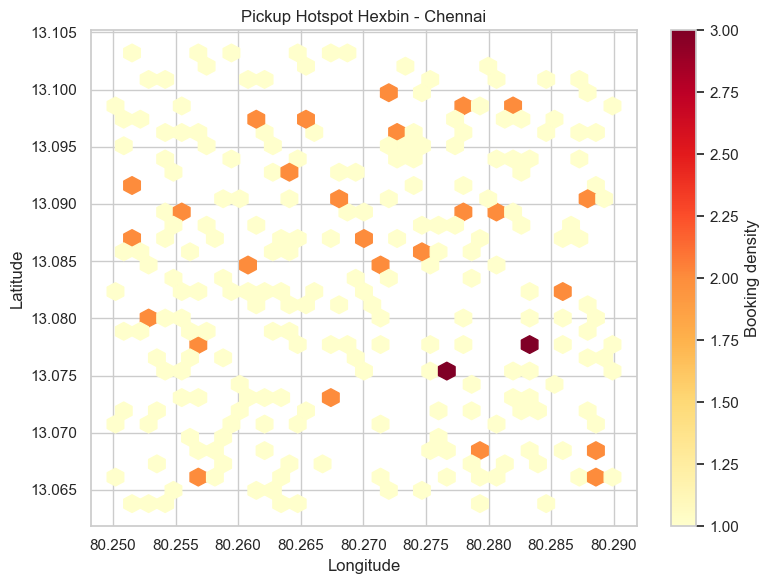

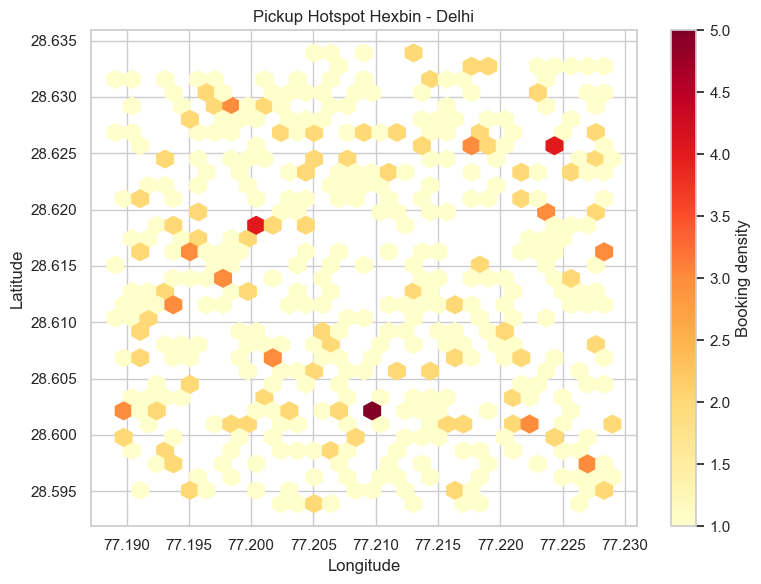

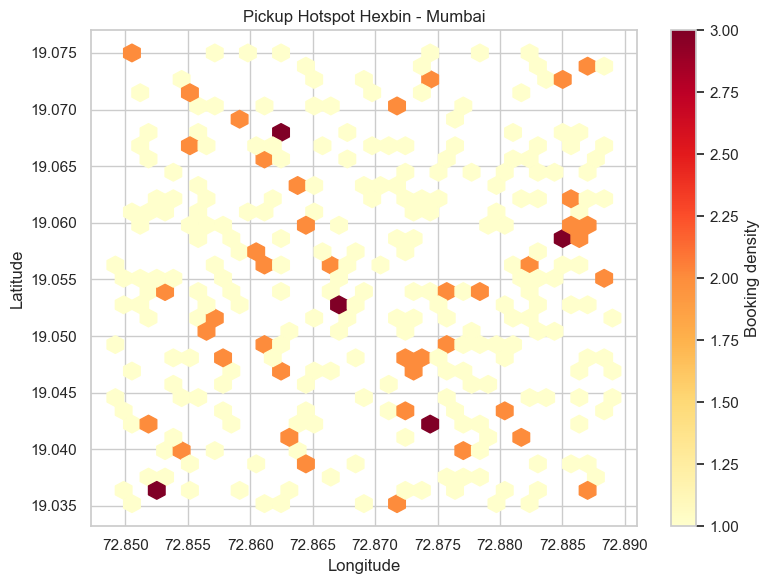

In [142]:
#Drop coordinates are not separately available; pickup geo points are used as hotspot proxy.
geo = df[df["is_completed"]].dropna(subset=["GPS_Lat", "GPS_Lon"]).copy()

# Identify hotspot zones
hotspots = (
    geo.assign(
        lat_bin=geo["GPS_Lat"].round(2),
        lon_bin=geo["GPS_Lon"].round(2)
    )
    .groupby(["City", "lat_bin", "lon_bin"], dropna=False)
    .size()
    .reset_index(name="bookings")
    .sort_values("bookings", ascending=False)
)

print(hotspots.head(7))

# Heatmap per city
for city, data in geo.groupby("City"):

    plt.figure(figsize=(8, 6))
    plt.hexbin(data["GPS_Lon"], data["GPS_Lat"], gridsize=30, cmap="YlOrRd", mincnt=1)
    plt.colorbar(label="Booking density")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Pickup Hotspot Hexbin - {city}")

    plt.tight_layout()
    plt.show()

## 14) Upsell/cross-sell opportunity flags (addons)


In [127]:
upsell = df.copy()
notes = upsell["Notes"].fillna("").str.lower()

upsell["addon_navigation"] = notes.str.contains("navigation")
upsell["addon_cleaning"] = notes.str.contains("clean")
upsell["addon_fuel_plan"] = notes.str.contains("fuel") | (upsell["Fuel_Level"].fillna(0.5) < 0.25)
upsell["addon_protection"] = upsell["Driver_Behavior"].isin(["Speeding", "Fast Driving"]) | upsell["Damage_Flag"].isin(["Minor", "Major"])

flag_cols = ["addon_navigation", "addon_cleaning", "addon_fuel_plan", "addon_protection"]
upsell["upsell_flag_count"] = upsell[flag_cols].sum(axis=1)
upsell["upsell_opportunity"] = upsell["upsell_flag_count"] > 0

upsell_summary = upsell.groupby("City", dropna=False).agg(
    rentals=("Reservation_ID", "count"),
    opportunities=("upsell_opportunity", "sum"),
).reset_index()
upsell_summary["opportunity_rate"] = 100 * upsell_summary["opportunities"] / upsell_summary["rentals"]

print(upsell_summary.sort_values("opportunity_rate", ascending=False))


        City  rentals  opportunities  opportunity_rate
3     Mumbai     1061            953             89.82
1    Chennai      798            714             89.47
2      Delhi     1627           1443             88.69
0  Bengaluru     1041            920             88.38


## 15) Cancellation rate and reasons analysis


         City Vehicle_Class  total_bookings  cancelled  cancellation_rate
30     Mumbai        Suzuki             129         53              41.09
12    Chennai           SUV              80         31              38.75
17      Delhi            EV             182         70              38.46
22      Delhi        Suzuki             200         76              38.00
5   Bengaluru         Sedan             136         51              37.50
7   Bengaluru        Toyota             117         43              36.75
24     Mumbai         Creta             187         67              35.83

Cancellation reason distribution:
  cancel_reason_bucket  count
3                Other    626
6          Unspecified    264
4      Schedule Change    146
0             Cleaning    132
1       Damage Concern    126
5              Traffic    110
2                 Fuel    105


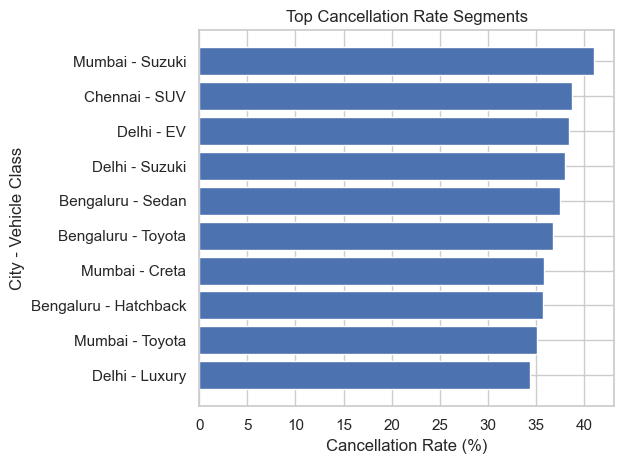

In [138]:
cancel = df.copy()

# Clean status
cancel["Booking_Status"] = cancel["Booking_Status"].str.strip().str.title()

# Correct flags
cancel["is_cancelled"] = cancel["Booking_Status"] == "Cancelled"
cancel["is_no_show"] = cancel["Booking_Status"] == "No_Show"


cancel_rate = cancel.groupby(["City", "Vehicle_Class"]).agg(
    total_bookings=("Reservation_ID", "count"),
    cancelled=("is_cancelled", "sum"),
).reset_index()

cancel_rate["cancellation_rate"] = 100 * cancel_rate["cancelled"] / cancel_rate["total_bookings"]

cancel_rate = cancel_rate[cancel_rate["total_bookings"] >= 50]

print(cancel_rate.sort_values("cancellation_rate", ascending=False).head(7))


notes = cancel["Notes"].fillna("").str.lower()

cancel["cancel_reason_bucket"] = np.select(
    [
        notes.str.contains("traffic"),
        notes.str.contains("fuel"),
        notes.str.contains("clean"),
        notes.str.contains("scratch|damage"),
        notes.str.contains("early pickup"),
        notes.str.contains("no notes"),
    ],
    ["Traffic", "Fuel", "Cleaning", "Damage Concern", "Schedule Change", "Unspecified"],
    default="Other",
)

reason_dist = cancel[cancel["is_cancelled"]].groupby("cancel_reason_bucket").size().reset_index(name="count")

print("\nCancellation reason distribution:")
print(reason_dist.sort_values("count", ascending=False))

import matplotlib.pyplot as plt

# Sort and take top 10 for clarity
plot_df = cancel_rate.sort_values("cancellation_rate", ascending=False).head(10)

# Create combined label
plot_df["label"] = plot_df["City"] + " - " + plot_df["Vehicle_Class"]

plt.figure()

plt.barh(plot_df["label"], plot_df["cancellation_rate"])

plt.xlabel("Cancellation Rate (%)")
plt.ylabel("City - Vehicle Class")
plt.title("Top Cancellation Rate Segments")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 16) Driver behavior scoring from telematics


     Customer_ID  trips  avg_driver_score
1256   CUST-1388      1             43.84
551    CUST-0596      1             45.39
1022   CUST-1126      1             46.20
1683   CUST-1858      1             47.13
811    CUST-0892      1             47.27
1580   CUST-1748      1             47.56
596    CUST-0644      1             48.20


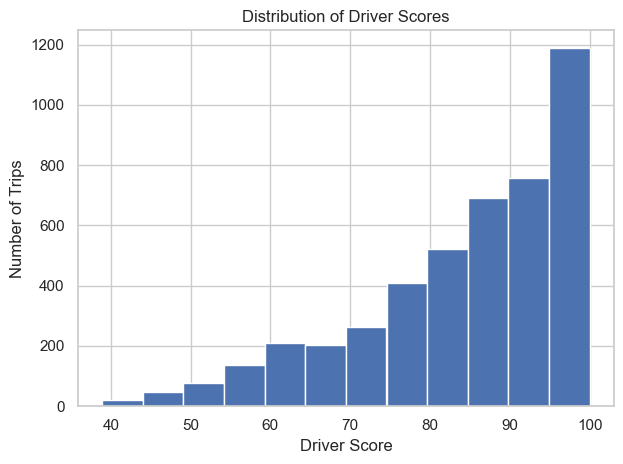

In [139]:
driver = df.copy()
driver["driver_score"] = 100

# Penalties
driver["driver_score"] -= np.where(driver["Speed"] > 120, 20,
                           np.where(driver["Speed"] > 100, 10, 0))

driver["driver_score"] -= np.where(driver["Driver_Behavior"].eq("Speeding"), 15,
                           np.where(driver["Driver_Behavior"].eq("Fast Driving"), 8, 0))

driver["driver_score"] -= np.where(driver["Damage_Flag"].eq("Major"), 15,
                           np.where(driver["Damage_Flag"].eq("Minor"), 5, 0))

np.random.seed(42)
driver["driver_score"] += np.random.normal(0, 5, size=len(driver))

# Keep range
driver["driver_score"] = driver["driver_score"].clip(0, 100)

# Aggregate
driver_summary = driver.groupby("Customer_ID").agg(
    trips=("Reservation_ID", "count"),
    avg_driver_score=("driver_score", "mean"),
).reset_index().sort_values("avg_driver_score")

print(driver_summary.head(7))

plt.figure()
plt.hist(driver["driver_score"], bins=12)

plt.xlabel("Driver Score")
plt.ylabel("Number of Trips")
plt.title("Distribution of Driver Scores")

plt.tight_layout()
plt.show()

## 17) Vehicle class mix optimization


         City Vehicle_Class  utilization   RevPAC  mix_score       mix_action
1   Bengaluru        Toyota         0.75 7,819.00       1.00   Increase share
7   Bengaluru        Luxury         0.44 5,757.00       0.42  Hold / optimize
18  Bengaluru           SUV         0.34 5,191.00       0.24     Reduce share
16  Bengaluru        Suzuki         0.35 4,608.00       0.19     Reduce share
22  Bengaluru     Hatchback         0.31 4,561.00       0.15     Reduce share
24  Bengaluru         Sedan         0.28 4,826.00       0.14     Reduce share
26  Bengaluru            EV         0.26 4,087.00       0.03     Reduce share


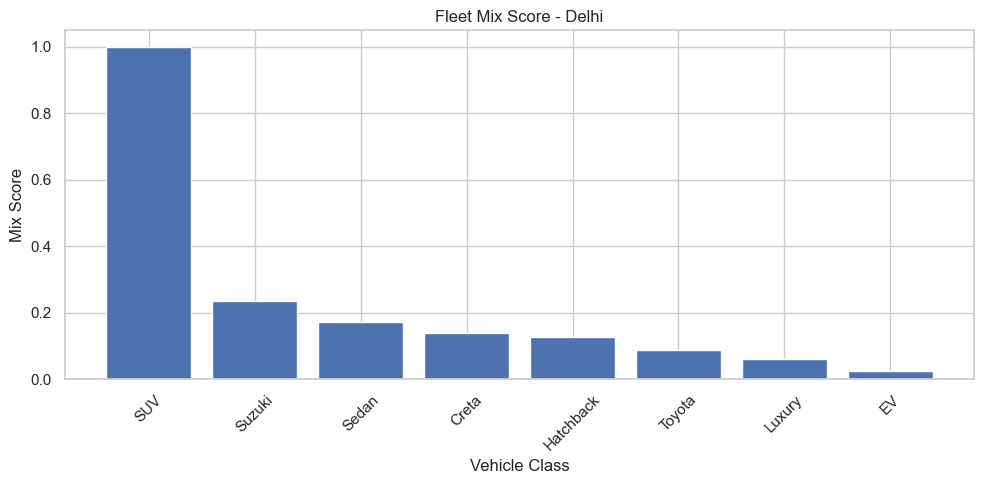

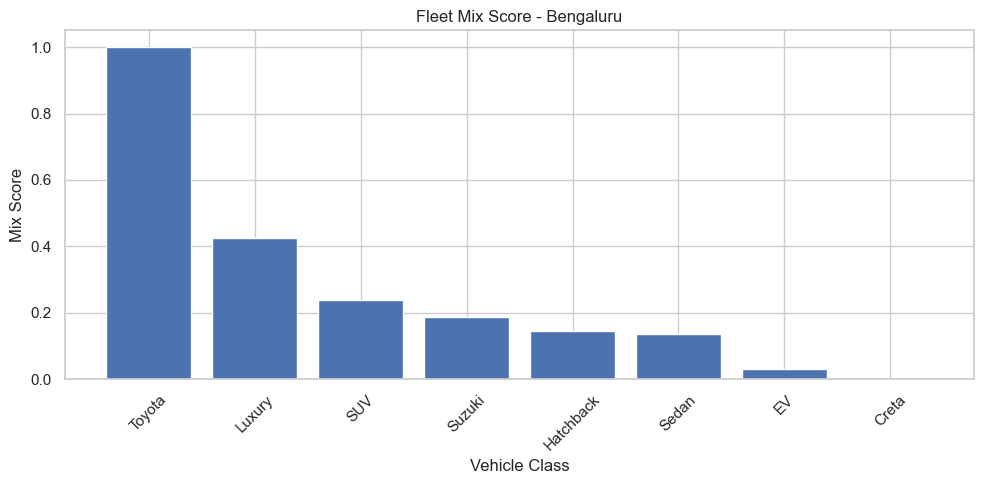

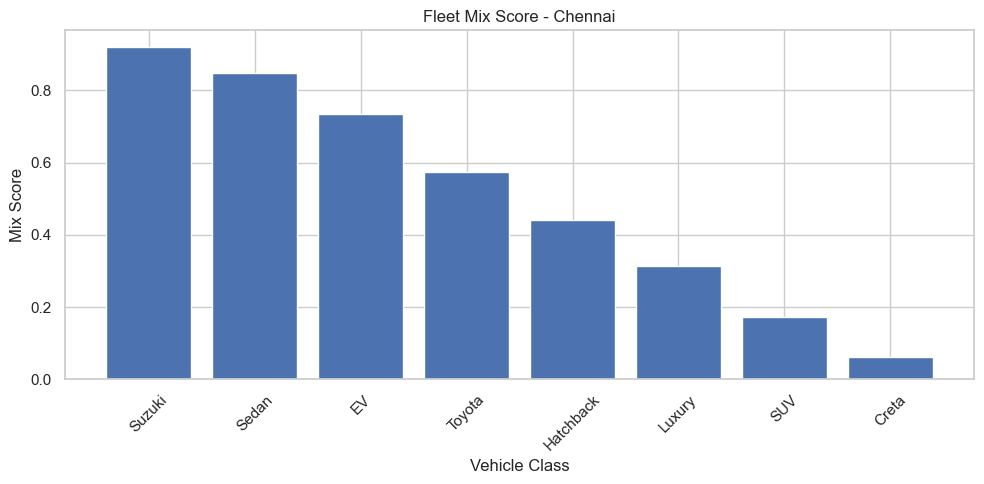

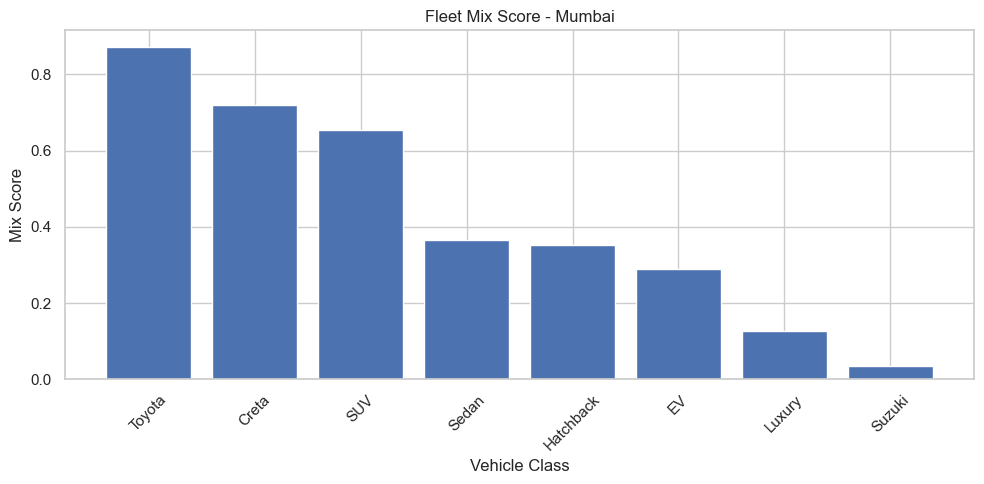

In [141]:
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

mix = util.merge(rev_metrics[["City", "Vehicle_Class", "RevPAC"]], on=["City", "Vehicle_Class"], how="left")
mix["fleet_share"] = mix.groupby("City")["available_cars"].transform(lambda s: s / max(s.sum(), 1))

mix["util_norm"] = mix.groupby("City")["utilization"].transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))
mix["rev_norm"] = mix.groupby("City")["RevPAC"].transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))
mix["mix_score"] = 0.6 * mix["util_norm"] + 0.4 * mix["rev_norm"]

mix["mix_action"] = np.where(mix["mix_score"] >= 0.66, "Increase share", np.where(mix["mix_score"] >= 0.33, "Hold / optimize", "Reduce share"))

final_mix = mix[
    ["City", "Vehicle_Class", "utilization", "RevPAC", "mix_score", "mix_action"]
].copy()

final_mix["utilization"] = final_mix["utilization"].round(2)
final_mix["RevPAC"] = final_mix["RevPAC"].round(0)
final_mix["mix_score"] = final_mix["mix_score"].round(2)

print(final_mix.sort_values(["City", "mix_score"], ascending=[True, False]).head(7))

# Create a copy of clean data
plot_df = mix[["City", "Vehicle_Class", "mix_score", "mix_action"]].copy()

# Loop through each city
for city in plot_df["City"].unique():
    city_df = plot_df[plot_df["City"] == city].sort_values("mix_score", ascending=False)

    plt.figure(figsize=(10, 5))
    plt.bar(city_df["Vehicle_Class"], city_df["mix_score"])

    plt.title(f"Fleet Mix Score - {city}")
    plt.xlabel("Vehicle Class")
    plt.ylabel("Mix Score")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 18) Lead-time price elasticity features


         City Vehicle_Class lead_time_bucket  price_elasticity
53    Chennai        Suzuki              NaN            -44.13
58      Delhi         Creta           Medium            -29.39
35    Chennai     Hatchback           Medium            -14.08
30    Chennai         Creta              NaN            -11.70
24  Bengaluru        Toyota           Medium            -10.52
14  Bengaluru           SUV           Medium             -9.51
76      Delhi         Sedan           Medium             -9.06


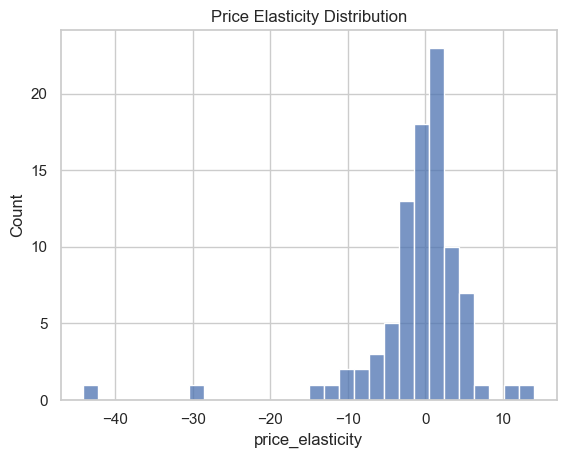

In [143]:
elastic = df.copy()

elastic["week"] = elastic["Booking_TS"].dt.to_period("W").astype(str)

weekly = elastic.groupby(["City", "Vehicle_Class", "week"], dropna=False).agg(
    bookings=("Reservation_ID", "count"),
    avg_rate=("Rate", "mean"),
    avg_lead_time=("lead_time_hours", "mean"),
).reset_index()

# NEW: Lead time segmentation
weekly["lead_time_bucket"] = pd.cut(
    weekly["avg_lead_time"],
    bins=[0, 6, 24, 72, 999],
    labels=["Last_Minute", "Short", "Medium", "Long"],
    include_lowest=True
)

def elasticity_proxy(g):
    g = g[(g["bookings"] > 0) & (g["avg_rate"] > 0)].dropna(subset=["bookings", "avg_rate"])

    if len(g) < 3 or g["avg_rate"].nunique() < 2:
        return np.nan
    x = np.log(g["avg_rate"])
    y = np.log(g["bookings"])
    return np.cov(x, y, bias=True)[0, 1] / (np.var(x) + 1e-9)


# UPDATED GROUPING
elasticity_table = (
    weekly.groupby(["City", "Vehicle_Class", "lead_time_bucket"], dropna=False)
    .apply(elasticity_proxy)
    .reset_index(name="price_elasticity")
)
print(elasticity_table.sort_values("price_elasticity").head(7))


# Visualization
sns.histplot(elasticity_table["price_elasticity"].dropna(), bins=30)
plt.title("Price Elasticity Distribution")
plt.show()

## 19) Fleet health score combining faults and usage


  Vehicle_ID Vehicle_Class  fleet_health_score health_band
0    CAR-001        Suzuki               69.81    Moderate
1    CAR-002        Toyota               64.36    Moderate
2    CAR-003     Hatchback               72.01    Moderate
3    CAR-005           SUV               48.21        Poor
4    CAR-006        Luxury               67.15    Moderate
5    CAR-007        Toyota               73.53    Moderate
6    CAR-008     Hatchback               65.27    Moderate


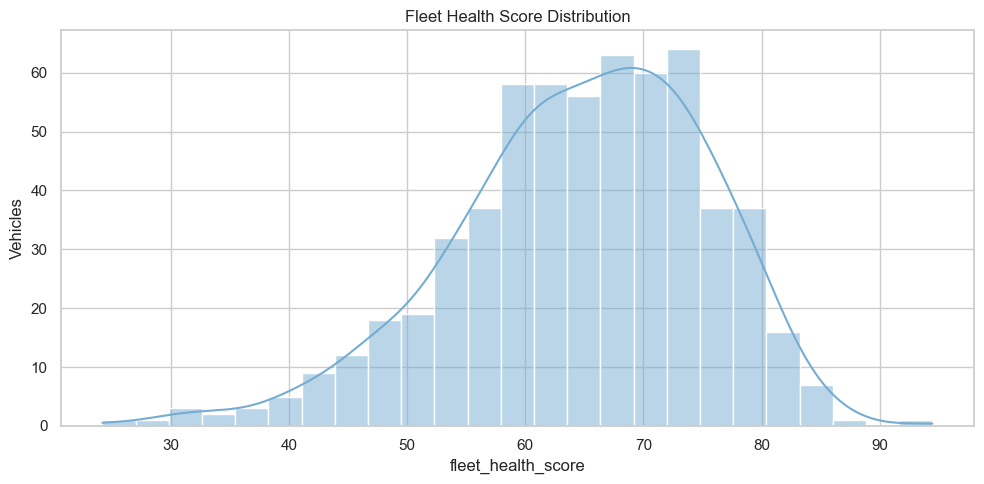

In [145]:
health_src = df.copy()
notes = health_src["Notes"].fillna("").str.lower()

health_src["fault_points"] = (
    np.where(health_src["Damage_Flag"].eq("Major"), 20, 0)
    + np.where(health_src["Damage_Flag"].eq("Minor"), 10, 0)
    + np.where(notes.str.contains("alert|malfunction|scratch"), 8, 0)
)

health_src["usage_hours_component"] = np.where(
    health_src["is_completed"],
    health_src["rental_hours"].fillna(0),
    0
)

health = health_src.groupby(["Vehicle_ID", "Vehicle_Class"], dropna=False).agg(
    fault_points=("fault_points", "sum"),
    usage_hours=("usage_hours_component", "sum"),
    avg_speed=("Speed", "mean"),
    rentals=("Reservation_ID", "count"),
).reset_index()

health["fault_norm"] = health["fault_points"] / (health["fault_points"].max() + 1e-9)
health["usage_norm"] = health["usage_hours"] / (health["usage_hours"].max() + 1e-9)

# UPDATED SPEED NORMALIZATION
max_speed = health["avg_speed"].max()
health["speed_norm"] = (health["avg_speed"].fillna(0) / max_speed).clip(0, 1)

health["fleet_health_score"] = 100 - (
    50 * health["fault_norm"] +
    30 * health["usage_norm"] +
    20 * health["speed_norm"]
)

health["fleet_health_score"] = health["fleet_health_score"].clip(0, 100)

health["health_band"] = pd.cut(
    health["fleet_health_score"],
    bins=[0, 50, 75, 100],
    labels=["Poor", "Moderate", "Healthy"],
    include_lowest=True
)

print(health[["Vehicle_ID","Vehicle_Class","fleet_health_score","health_band"]].head(7))

# Visualization: fleet health score distribution
health_plot = health.dropna(subset=["fleet_health_score"]).copy()

if health_plot.empty:
    print("No fleet health records available for plotting.")
else:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=health_plot, x="fleet_health_score", bins=25, kde=True, color="#74add1")
    plt.title("Fleet Health Score Distribution")
    plt.xlabel("fleet_health_score")
    plt.ylabel("Vehicles")
    plt.tight_layout()
    plt.show()

## 20) Churn likelihood for subscription rentals


Subscription proxy: customers with at least 3 bookings in the dataset are treated as subscription-like customers.


             total_bookings         last_booking  bookings_recent_90  bookings_prev_90  days_since_last_booking  drop_ratio  recency_norm  drop_norm  churn_likelihood churn_band
Customer_ID                                                                                                                                                                      
CUST-1190                 7  2025-05-13 00:00:00                0.00              1.00                      175        1.00          0.97       0.70              0.90       High
CUST-1472                 6  2025-05-14 00:00:00                0.00              1.00                      174        1.00          0.97       0.70              0.85       High
CUST-0653                 6  2025-05-17 00:00:00                0.00              1.00                      171        1.00          0.95       0.70              0.85       High
CUST-0356                 7  2025-06-06 00:00:00                0.00              2.00                      15

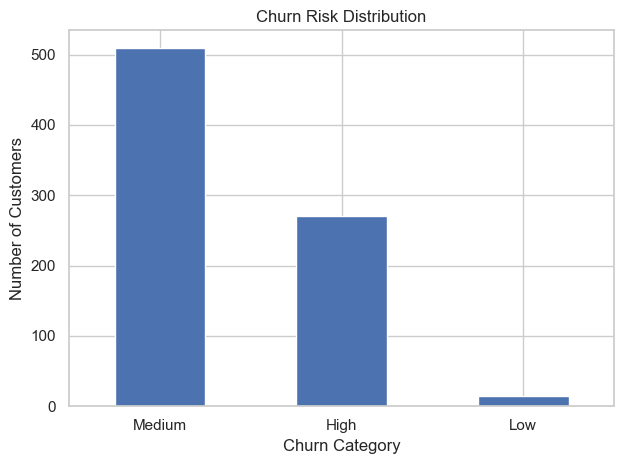

In [146]:
churn_src = df.copy()
churn_src["booking_date"] = churn_src["Booking_TS"].dt.floor("D")


cust_counts = churn_src.groupby("Customer_ID")["Reservation_ID"].count().rename("total_bookings")
subs = cust_counts[cust_counts >= 3].index
sub_df = churn_src[churn_src["Customer_ID"].isin(subs)].copy()

snapshot = sub_df["booking_date"].max() + pd.Timedelta(days=1) if not sub_df.empty else pd.Timestamp.today().normalize()

last_booking = sub_df.groupby("Customer_ID")["booking_date"].max().rename("last_booking")
sub_df["days_ago"] = (snapshot - sub_df["booking_date"]).dt.days

recent_90 = sub_df[sub_df["days_ago"] <= 90].groupby("Customer_ID")["Reservation_ID"].count().rename("bookings_recent_90")
prev_90 = sub_df[(sub_df["days_ago"] > 90) & (sub_df["days_ago"] <= 180)] \
    .groupby("Customer_ID")["Reservation_ID"].count().rename("bookings_prev_90")

churn = pd.concat([cust_counts, last_booking, recent_90, prev_90], axis=1).fillna(0)
churn = churn.loc[churn.index.isin(subs)].copy()
churn["days_since_last_booking"] = (snapshot - pd.to_datetime(churn["last_booking"])).dt.days

churn["drop_ratio"] = np.where(
    churn["bookings_prev_90"] > 0,
    (churn["bookings_prev_90"] - churn["bookings_recent_90"]) / churn["bookings_prev_90"],0)

churn["recency_norm"] = (churn["days_since_last_booking"] / 180).clip(0, 1)
churn["drop_norm"] = (churn["drop_ratio"] * 0.7).clip(0, 1)

churn["churn_likelihood"] = (
    0.4 * churn["recency_norm"] +
    0.3 * churn["drop_norm"] +
    0.3 * (churn["total_bookings"] / churn["total_bookings"].max())
).clip(0, 1)

churn["churn_band"] = pd.cut(
    churn["churn_likelihood"],
    bins=[-0.01, 0.4, 0.7, 1.0],
    labels=["Low", "Medium", "High"]
)

print(churn.sort_values("churn_likelihood", ascending=False).head(7))

print("\nChurn Risk Distribution:")
print(churn["churn_band"].value_counts())

plt.figure()
churn["churn_band"].value_counts().plot(kind="bar")

plt.xlabel("Churn Category")
plt.ylabel("Number of Customers")
plt.title("Churn Risk Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()